# Heart Stroke Prediction: Handling Outliers

> **Don't remove what you don't understand.**

Scikit-learn does not have a single "OutlierHandler" class that works like a standard imputer. Instead, it provides two distinct approaches: **Detection** (identifying which rows are outliers) and **Robust Transformation** (modifying the data so outliers don't break the model).

Here is how to handle outliers using built-in sklearn tools:



### 1. Robust Scaling (The "Neutralize" Approach)

Before you delete data, you should try to make your model immune to it. Standard scalers (like `StandardScaler`) use the **Mean**, which is heavily pulled by outliers. `RobustScaler` uses the **Median** and **Interquartile Range (IQR)**.

* **How it works:** It centers the data at the median and scales it based on the 25th and 75th percentiles.
* **Best for:** When you want to keep the outlier data points (because they might be real clinical signals) but don't want them to dominate the feature weights.

```python
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

```


### 2. Detection via Unsupervised Learning

If you want to find and remove outliers (or flag them), sklearn provides "Novelty and Outlier Detection" algorithms. These return `1` for inliers and `-1` for outliers.

| Algorithm | Logic | Best For... |
| --- | --- | --- |
| **IsolationForest** | Isolates observations by randomly partitioning features. Outliers are easier to isolate (shorter paths). | High-dimensional data and most common choice. |
| **LocalOutlierFactor (LOF)** | Compares the local density of a point to its neighbors. | Finding "local" outliers (points that are weird relative to their immediate neighbors). |
| **EllipticEnvelope** | Assumes the data follows a Gaussian distribution and fits an ellipse around central points. | Normally distributed numerical data. |


### 3. Outlier-Robust Regressors

If you are doing regression (e.g., predicting a continuous stroke risk score), some models have "built-in" outlier handling by changing the loss function.

* **HuberRegressor:** Instead of squaring the error (), it treats small errors as squared and large errors (outliers) as linear (). This prevents the model from "chasing" the outliers.
* **RANSACRegressor:** Fits a model to a random subset of "inliers" and ignores the rest.


### 4. Implementation in your Pipeline

In your clinical project, you should avoid deleting rows manually. Instead, use a **PowerTransformer** or **QuantileTransformer**. These "squash" the distribution into a normal shape, naturally pulling outliers closer to the mean.

```python
from sklearn.preprocessing import PowerTransformer

# This handles outliers by mapping data to a normal distribution
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)

```

### Strategic Advice for Stroke Prediction:

In clinical data, an "outlier" (like a BMI of 60 or a Glucose of 300) is often a **real person** who is at the **highest risk** of a stroke.

1. **Do not delete them.**
2. Use **RobustScaler** or **PowerTransformer** to normalize their influence.
3. Use **IsolationForest** to create a new binary feature called `is_extreme_case`. This lets the model know, "This patient is an outlier," without the numerical value breaking the math.

**See Run Results :** [https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow](https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow/#/)

In [ ]:
# TRIGGER_FLAG: run
# KAGGLE_CONFIG: enable_gpu = false
# KAGGLE_CONFIG: enable_tpu = false
# KAGGLE_CONFIG: keywords = ["healthcare", "classification", "data-cleaning"]
# KAGGLE_CONFIG: dataset_sources = ["rahulshelke98/healthcare-dataset-stroke-data-csv"]
# KAGGLE_CONFIG: kernel_sources = ["rahulshelke98/01-02-data-quality-correction", "rahulshelke98/02-03-handling-missing-values"]

## Required Installtion

In [ ]:
import os
import sys

# Check if running in Kaggle Cloud Environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    print("--- Kaggle Environment Detected: Installing Cloud Dependencies ---")
    # 1. Install general cloud dependencies
    os.system(f"{sys.executable} -m pip install -q mlflow dagshub")
    
    # 2. Clone the specific branch of the repository
    print("Cloning repository...")
    # os.system("git clone -b feat/notebooks https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git")
    os.system(f"{sys.executable} -m pip install -q git+https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git@feat/notebooks")
    
else:
    print("--- Local/Non-Kaggle Environment Detected: Skipping Installation ---")
    # Local packages should ideally be pre-managed via your local uv environment

--- Local/Non-Kaggle Environment Detected: Skipping Installation ---


## Smart Environment Detection & Secrets Setup

In [ ]:
# PRODUCTION MLOPS NOTEBOOK
# Note: This notebook runs automatically in an headless CI/CD pipeline.
# If you fork this notebook to run it yourself, make sure to set up your 
# own DagsHub repository variables or track experiments locally.

import os
import mlflow
from dotenv import load_dotenv

# 1. Safely retrieve credentials from Kaggle's internal secure vault
try:
    # 1. Detect if running inside Kaggle's container
    IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

    if IS_KAGGLE:
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    else:
        load_dotenv()
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME", "Rahul-404")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    
    # Replace this with your actual DagsHub repo name
    REPO_NAME = "heart-stroke-prediction"
    
    # 2. Inject environment variables that the MLflow client natively looks for
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    
    # 3. Set the remote tracking URI to point to DagsHub
    tracking_uri = f"https://dagshub.com/{DAGSHUB_USERNAME}/{REPO_NAME}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
    
    print("Successfully connected to DagsHub MLflow tracking server!")
except Exception as e:
    # print(f"Local or non-Kaggle execution environment detected: {e}")
    print(f"Error establishing MLflow/DagsHub context: {e}")

Successfully connected to DagsHub MLflow tracking server!


## Unified Path Setup Strategy

In [ ]:
import os
from pathlib import Path

# 1. Reuse your environment checker flag
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    # --- KAGGLE CLOUD PATH CONTEXT ---
    # Fetch environment variables injected by your Kaggle configuration
    KAGGLE_USER = os.environ.get("KAGGLE_USER")
    DATASET_SLUG = os.environ.get("KAGGLE_DATASET_NAME")
    NOTEBOOK_1 = "01-02-data-quality-correction"
    NOTEBOOK_2 = "02-03-handling-missing-values"

    # Kaggle mounts datasets directly under /kaggle/input/dataset-slug
    INPUT_DATA_DIR = Path(f"/kaggle/input/datasets/{KAGGLE_USER}/{DATASET_SLUG}")
    INPUT_ARTIFACT_1_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_1}")
    INPUT_ARTIFACT_2_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_2}")

    if not INPUT_DATA_DIR.exists():
        raise FileNotFoundError(f"Kaggle Input Directory does not exist: {INPUT_DATA_DIR}")

    if not INPUT_ARTIFACT_1_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_1_DIR}")
    
    if not INPUT_ARTIFACT_2_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_2_DIR}")
    
    INPUT_DIR = {
        'data': INPUT_DATA_DIR,
        'data_correct': INPUT_ARTIFACT_1_DIR,
        'handle_missing': INPUT_ARTIFACT_2_DIR,
        'handle_missing_val': INPUT_ARTIFACT_2_DIR
    }
    
    # Kaggle strictly allows file writing ONLY inside /kaggle/working
    OUTPUT_DIR = Path("/kaggle/working")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

else:
    # --- LOCAL ENVIRONMENT PATH CONTEXT ---
    current_directory = Path.cwd()

    # Keeps your local repo clean by saving local run artifacts into an artifacts folder
    OUTPUT_DIR = current_directory / "notebooks" / "artifact"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Points to your local repository structure (e.g., repository_root/notebooks/data/)
    INPUT_DATA_DIR = current_directory / "notebooks" / "data"
    INPUT_ARTIFACT_DIR = current_directory / "notebooks" / "artifact"

    if not INPUT_DATA_DIR.exists():
        raise FileNotFoundError(f"Local Input Directory does not exist: {INPUT_DATA_DIR}")

    if not INPUT_ARTIFACT_DIR.exists():
        raise FileNotFoundError(f"Local Artifact Directory does not exist: {INPUT_ARTIFACT_DIR}")

    INPUT_DIR = {
        'data': INPUT_DATA_DIR,
        'data_correct': INPUT_ARTIFACT_DIR,
        'handle_missing': INPUT_ARTIFACT_DIR,
        'handle_missing_val': INPUT_ARTIFACT_DIR
    }

print("--- PATH SUMMARY ---")
print(f"Execution Target:    {'Kaggle Cloud' if IS_KAGGLE else 'Local Machine'}")
print(f"Reading Input From:  {INPUT_DIR}")
print(f"Writing Outputs To: {OUTPUT_DIR}")

--- PATH SUMMARY ---
Execution Target: Local Machine
Reading Input From: /Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/data
Writing Outputs To: /Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact


### Library version problem

In [9]:
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns

print("Seaborn version: ",sns.__version__)
print("Numpy version: ",np.__version__)
print("Matplotlib version: ",matplotlib.__version__)

# Seaborn version:  0.12.2 # this gives bar plot color, but heatmap have error
# Numpy version:  1.24.4
# Seaborn version:  0.13.0 # this gives bar plot no color , but heatmap no error solved

# matplot version : 3.7.3
# 3 solves all the problems

Seaborn version:  0.13.2
Numpy version:  2.4.6
Matplotlib version:  3.10.9


## Importing Libraries

In [10]:
from heart_stroke_prediction.analyze.basic_data_inspection import (DataInspector,
                                               DataTypesInspectionStrategy,
                                               SummaryStatisticsInspectionStrategy,
                                               )

# outlier handling
from heart_stroke_prediction.analyze.outlier.visualize import OutlierVisualizer
from heart_stroke_prediction.analyze.outlier.detection import OutlierDetector

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
# setting config
from sklearn import set_config
set_config(transform_output="pandas")

# libraries
import cloudpickle

# data manupulation
import pandas as pd
from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
# DATA_FILES = os.listdir(INPUT_DIR)
# DATA_FILES

['healthcare-dataset-stroke-data.csv']

In [ ]:
# ARTIFACT_FILES = os.listdir(OUTPUT_DIR)
# ARTIFACT_FILES

['missing_imputer_validation_pipeline.pkl',
 'data_correction_pipeline.pkl',
 'heart_stroke_data.csv',
 'missing_imputer_pipeline.pkl']

In [ ]:
DATA_FILE_NAME = {
    'raw': Path(INPUT_DIR['data'], 'healthcare-dataset-stroke-data.csv'),
    'clean': Path(INPUT_DIR['data_correct'], 'heart_stroke_data.csv'),
}

ARTIFACT_FILE_NAME = {
    'data_correct': Path(INPUT_DIR['data_correct'], 'data_correction_pipeline.pkl'),
    'handle_missing': Path(INPUT_DIR['handle_missing'], 'missing_imputer_pipeline.pkl'),
    'handle_missing_val': Path(INPUT_DIR['handle_missing_val'], 'missing_imputer_validation_pipeline.pkl'),
    'handle_outlier': Path(OUTPUT_DIR, 'outlier_handler_pipeline.pkl'),
}

### Set Experiment Name

In [14]:
experiment_name = "02_04_Handling_Outliers"
experiment_tags = {
    "experiment_type": "Classification",
    "project": "heart_stroke_risk_stratification",
    "team": "Data_Science_Core"
}

try:
    experiment_id = mlflow.create_experiment(name=experiment_name, tags=experiment_tags)
except Exception:
    # If it already exists, fetch its ID
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

# 3. Set it as the active experiment
mlflow.set_experiment(experiment_id=experiment_id)

KeyboardInterrupt: 

### Set Run Name

In [ ]:
# Starts a global active run
mlflow.start_run(run_name="Handling_Outliers_Session")

## Read Data

In [15]:
with open(ARTIFACT_FILE_NAME["data_correct"], "rb") as f:
    pipeline = cloudpickle.load(f)

In [16]:
df = pipeline.fit_transform(pd.read_csv(DATA_FILE_NAME['raw']))

### **Show Top 5 Records**

In [17]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


### **Feature Information**

- Here we used the heart stroke dataset that is available in the kaggle website for our analysis. This datasets consists of total 12 attributes. The complete description of the attributes used in the proposed work is given below.

- **id**: This attribute means person's id. it's numerical data.

- **Age**: This attribute means a persons age. it's numerical data.

- **Gender**: This attribute means a person's gender, it's categorical data.

- **Hypertension**: This attribute means that this person is hypertensive or not. it's numerical data.

- **work type**: This attribute represents the person work scenario. it's categorical data.

- **residence type**: This attribute represnts the person work scenario. it's categorical data.

- **heart disease**: This attribute means wheather this person has a heart disease person or not. it's numerical data.

- **avg_glucose_level**: This attribute means what was the level of a person's glucose condition. it's numercial data.

- **Bmi**: This attribute represents a person's married status. it's categorical data.

- **ever_married**: This attribute represents a person's married status. it's categorical data.

- **smoking_status**: This attribute means a person's smoking condition. it's categorical data.

- **Stroke**: This attribute means a person previously had a choise or not.

### **Shape of the dataset**

In [19]:
df.shape

(5109, 12)

In [20]:
inspector = DataInspector(DataTypesInspectionStrategy())
inspector.execute_inspection(df)


Data Types and Non-null Counts:
<class 'pandas.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   str    
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   str    
 6   work_type          5109 non-null   str    
 7   residence_type     5109 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     3565 non-null   str    
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 666.9 KB
None


### **Summary of the dataset**

In [21]:
inspector.set_strategy(SummaryStatisticsInspectionStrategy())
inspector.execute_inspection(df)


Summary Statistics (Numerical Features):
                 id          age  hypertension  heart_disease  \
count   5109.000000  5109.000000   5109.000000    5109.000000   
mean   36513.985516    43.229986      0.097475       0.054022   
std    21162.008804    22.613575      0.296633       0.226084   
min       67.000000     0.080000      0.000000       0.000000   
25%    17740.000000    25.000000      0.000000       0.000000   
50%    36922.000000    45.000000      0.000000       0.000000   
75%    54643.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level         bmi       stroke  
count        5109.000000  4908.00000  5109.000000  
mean          106.140399    28.89456     0.048738  
std            45.285004     7.85432     0.215340  
min            55.120000    10.30000     0.000000  
25%            77.240000    23.50000     0.000000  
50%            91.880000    28.10000     0.000000  
75%     

## **Statistical Inferences**

- Median age of population is 45 years.
- 25% of the population is aged below 25
- Another 25% is aged above 60 and remaining in between threse ages
- About 9.7% and 5.4% of population suffers from hypertension with heart disease respectively.
- People with higher BMI (BMI > 45) are less represented. This can affect our machine learning models significantly.

## **Target Distribution**

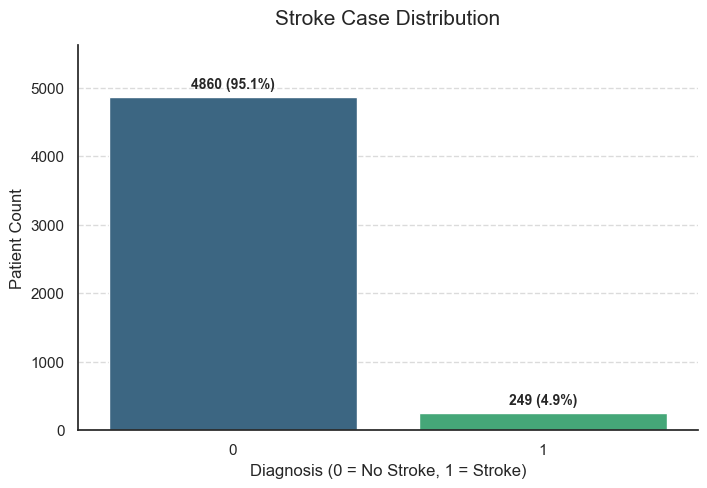

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set a clean style
sns.set_theme(style="white")
plt.figure(figsize=(8, 5))

# 2. Create the plot
# (Note: hue=x is added to avoid future warnings; palette is applied)
ax = sns.countplot(data=df, x='stroke', palette='viridis')

if ax.get_legend() is not None:
    ax.get_legend().remove()

# 3. Add the faint dotted grid
# axis='y' keeps it to horizontal lines only
# linestyle='--' or ':' for dots/dashes
# alpha=0.3 makes it "faint"
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # This ensures the grid stays BEHIND the bars

# 4. Add exact count and percentage labels
total = len(df) # Get total rows for percentage calculation
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%' # Calculate %
    
    # Label format: Count (Percentage%)
    label = f'{count} ({percentage})'
    
    ax.annotate(label, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
# 5. Final Polish
plt.title('Stroke Case Distribution', fontsize=15, pad=15)
plt.xlabel('Diagnosis (0 = No Stroke, 1 = Stroke)', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.ylim(0, total * 1.1) # Add some headspace for labels
sns.despine()
plt.show()

## **Correcting feature categarization :**

In [23]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
# TEXT_FEATURES = ["Name"]
CAT_FEATURES = [col for col in df.columns if df[col].dtype == "O" if col not in TARGET_COL+ID_COL]
NUM_FEATURES = [col for col in df.columns if df[col].dtype != "O" if col not in TARGET_COL+ID_COL]

In [24]:
print("id column: ", ID_COL)
print("target column: ", TARGET_COL)
print("categorical columns: ", CAT_FEATURES)
print("numerical columns: ", NUM_FEATURES)

id column:  ['id']
target column:  ['stroke']
categorical columns:  []
numerical columns:  ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


In [25]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
CAT_FEATURES = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status', 'missingindicator_smoking_status', 'missingindicator_bmi']
NUM_FEATURES = ['age', 'avg_glucose_level', 'bmi']

# **Visual Outlier Analysis (boxplot):**

**Aim:** To see if outliers even exist and how extreme they look.


In [26]:
# visualize outliers
visualize = OutlierVisualizer(df)

<!-- ![Image](https://www.etsy.com/il-en/listing/1465441181/bmi-chart-height-weight-guide-printable) -->

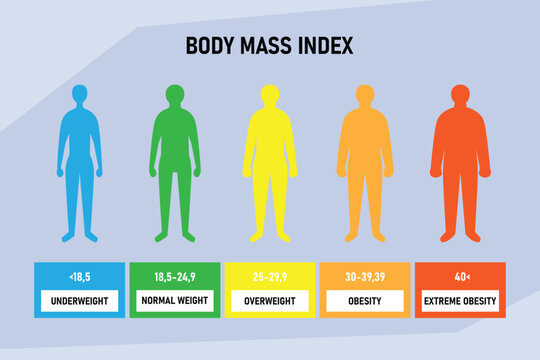

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_custom_boxplots(df, columns_to_plot):
    """
    Plots boxplots for specific columns in a 4-column grid.
    Red box = Outliers detected | Green box = No outliers
    """
    n_cols = 4
    n_rows = math.ceil(len(columns_to_plot) / n_cols)
    
    # Adjust height based on number of rows
    plt.figure(figsize=(20, 5 * n_rows))
    
    for i, col in enumerate(columns_to_plot):
        if col not in df.columns:
            print(f"Warning: {col} not found in DataFrame.")
            continue
            
        # 1. Calculate Outliers using IQR Logic
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Check for points outside whiskers
        has_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).any()
        
        # 2. Pick Color
        box_color = 'salmon' if has_outliers else 'lightgreen'
        
        # 3. Plotting
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(y=df[col], color=box_color, width=0.5)
        
        # 4. Styling & Labels
        status = "OUTLIERS" if has_outliers else "CLEAN"
        plt.title(f"{col}\n({status})", 
                  fontsize=12, 
                  fontweight='bold', 
                  color='darkred' if has_outliers else 'darkgreen')
        
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.ylabel("Range")

    plt.tight_layout()
    plt.show()

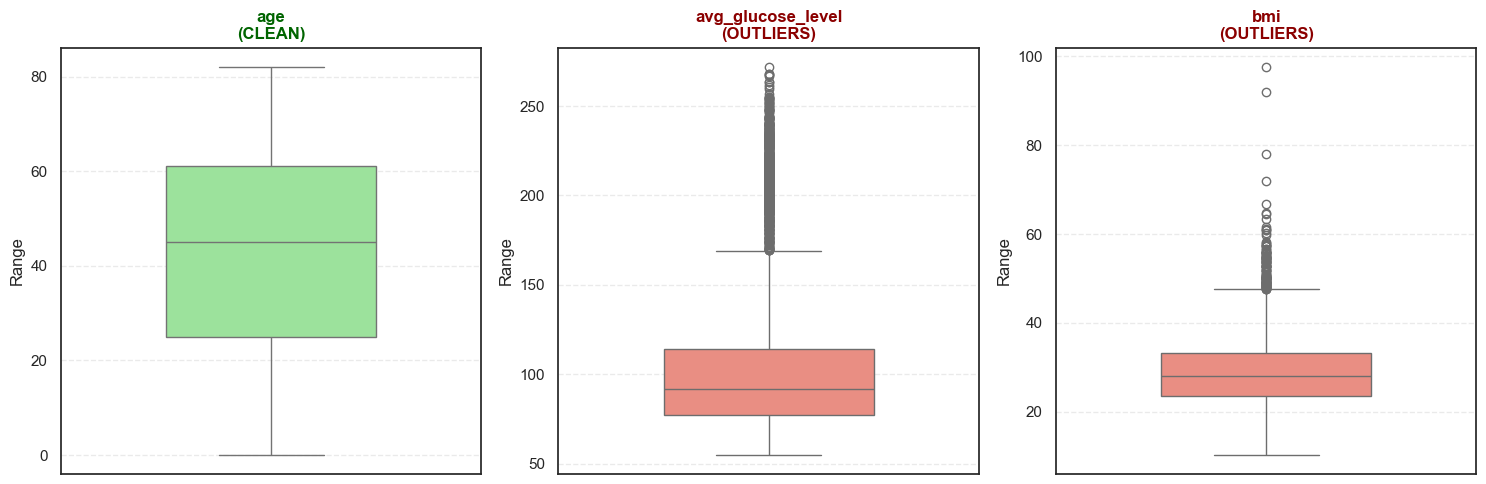

In [28]:
my_cols = ['age', 'avg_glucose_level', 'bmi']
plot_custom_boxplots(df, my_cols)

### **BMI**

In [29]:
# visualize.plot_boxplot('bmi')

### **Avg Glucose Level**

In [30]:
# visualize.plot_boxplot('avg_glucose_level')

- there outliers present in `bmi` & `avg_glucose_level`

# **Statistical Outlier Detection (IQR & Z-Score)**

In [31]:
# detect outliers
detect = OutlierDetector(df)

## BMI

In [32]:
iqr_outliers_bmi = detect.find_outliers_iqr('bmi')


--- IQR Outlier Report for 'bmi' ---
Total Rows: 5109
Bounds: [9.10, 47.50]
Outliers Found (Count/Percent): 110 (2.15%)


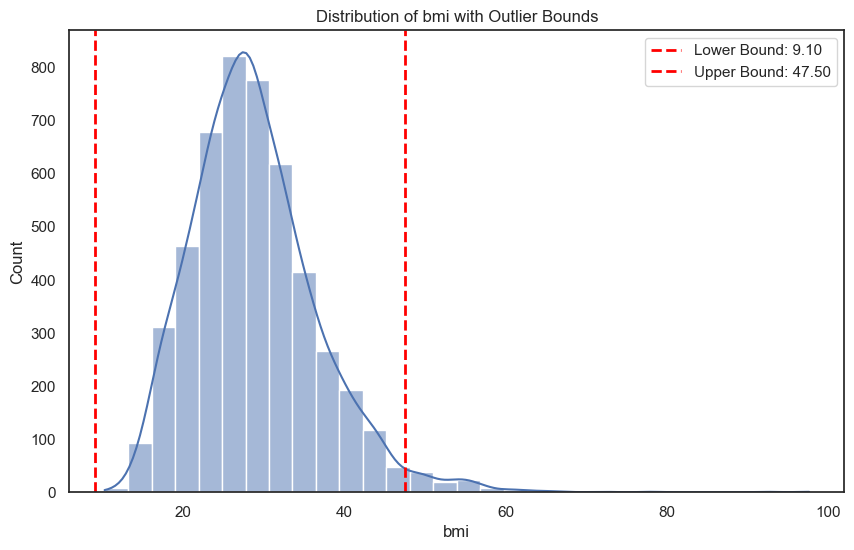

In [33]:
visualize.plot_distribution_with_bounds('bmi', iqr_outliers_bmi['lower_bound'], iqr_outliers_bmi['upper_bound'])

In [34]:
zscore_outliers_bmi = detect.find_outliers_zscore('bmi')


--- Z-Score Outlier Report for 'bmi' (Threshold +/- 3.0 SD) ---
Total Rows: 5109
Bounds: [5.33, 52.46]
Outliers Found (Count/Percent): 58 (1.14%)


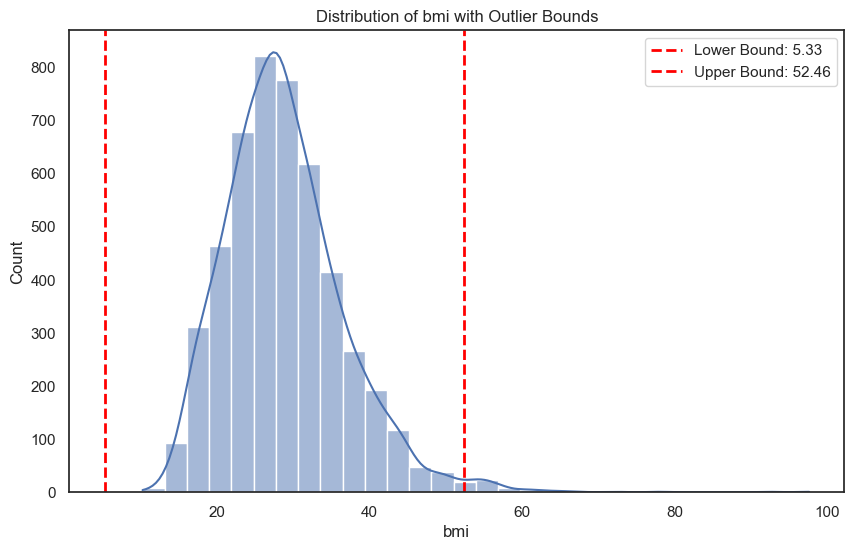

In [35]:
visualize.plot_distribution_with_bounds('bmi', zscore_outliers_bmi['lower_bound'], zscore_outliers_bmi['upper_bound'])

## Avg Glucose Level

In [36]:
iqr_outliers_agl = detect.find_outliers_iqr('avg_glucose_level')


--- IQR Outlier Report for 'avg_glucose_level' ---
Total Rows: 5109
Bounds: [21.96, 169.37]
Outliers Found (Count/Percent): 627 (12.27%)


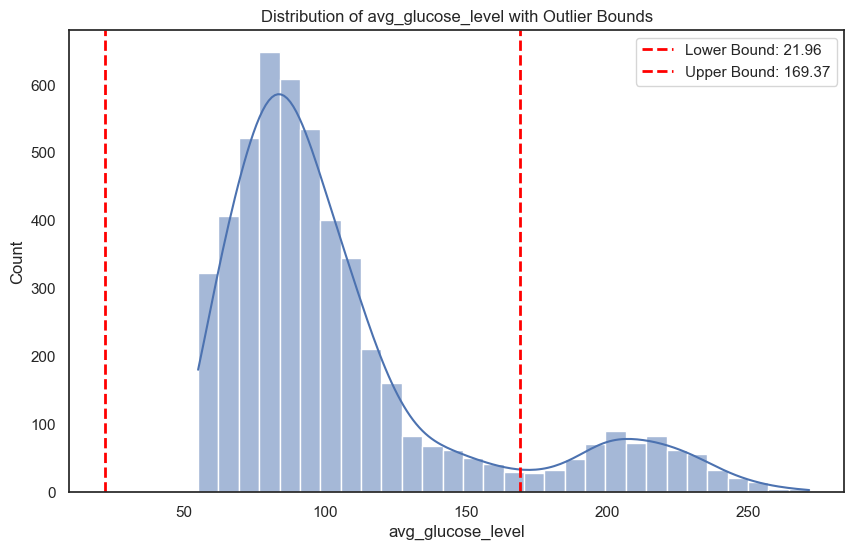

In [37]:
visualize.plot_distribution_with_bounds('avg_glucose_level', iqr_outliers_agl['lower_bound'], iqr_outliers_agl['upper_bound'])

In [38]:
df['avg_glucose_level'].max()

np.float64(271.74)

In [39]:
zscore_outliers_agl = detect.find_outliers_zscore('avg_glucose_level')


--- Z-Score Outlier Report for 'avg_glucose_level' (Threshold +/- 3.0 SD) ---
Total Rows: 5109
Bounds: [-29.71, 242.00]
Outliers Found (Count/Percent): 49 (0.96%)


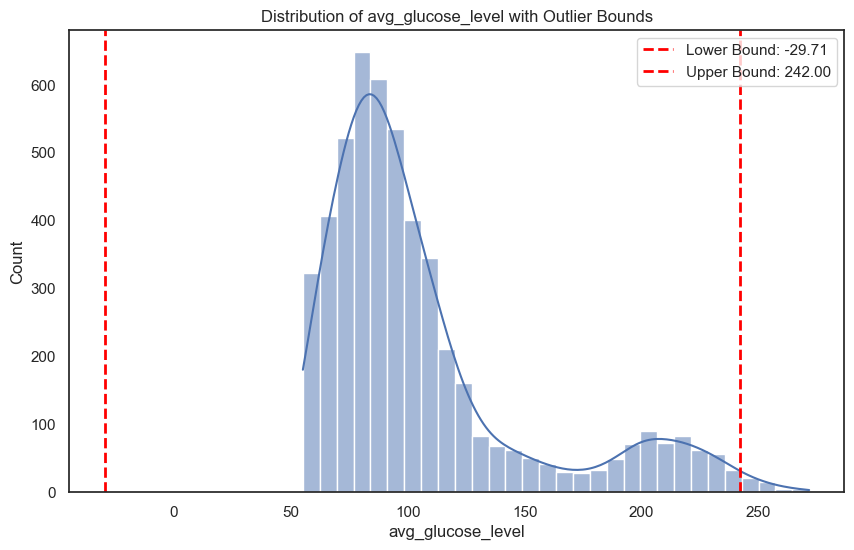

In [40]:
visualize.plot_distribution_with_bounds('avg_glucose_level', zscore_outliers_agl['lower_bound'], zscore_outliers_agl['upper_bound'])

# **Outlier Treatment**

Fetaures:

- `bmi`: numerical feature
- `avg_glucose_level`: numerical feature

Approach:

Scenario |	Best Technique
---|---
Outlier is a clear **mistake/error**	| **Trim** (Delete)
Data is **skewed** but valid |	**Log Transform**
You want to keep the row but **limit its influence**	| **Capping** (Winsorize)
You are building a **Linear/Distance-based model**	| **Robust Scaling**

- Metrics:
    1. Recall
    2. PR-AUC
    3. Balanced Accuracy
    4. F2-score
    5. Calibration

In [41]:
# import numpy as np
# import pandas as pd
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.utils.validation import check_is_fitted

# class IQROutlierHandler(BaseEstimator, TransformerMixin):
#     def __init__(self, factor=1.5, add_indicator=False):
#         self.factor = factor
#         self.add_indicator = add_indicator
        
#     def fit(self, X, y=None):
#         # FIX 1: Capture names safely from DataFrame or create dummy names for NumPy
#         if hasattr(X, "columns"):
#             self.feature_names_in_ = list(X.columns.astype(str))
#         else:
#             self.feature_names_in_ = [f"x{i}" for i in range(X.shape[1])]
        
#         X_df = pd.DataFrame(X, columns=self.feature_names_in_)
#         self.bounds_ = {}
        
#         for col in self.feature_names_in_:
#             q1, q3 = np.percentile(X_df[col].dropna(), [25, 75])
#             iqr = q3 - q1
#             self.bounds_[col] = (q1 - self.factor * iqr, q3 + self.factor * iqr)
#         return self

#     def transform(self, X):
#         check_is_fitted(self)
        
#         # FIX 2: Always wrap in DataFrame using the names saved during FIT
#         X_out = pd.DataFrame(X, columns=self.feature_names_in_)
#         indicators = []

#         for col in self.feature_names_in_:
#             low, high = self.bounds_[col]
            
#             if self.add_indicator:
#                 # 1 if outside bounds, 0 if inside
#                 is_outlier = ((X_out[col] < low) | (X_out[col] > high)).astype(int)
#                 indicators.append(pd.Series(is_outlier, name=f"{col}_outlier", index=X_out.index))
            
#             X_out[col] = np.clip(X_out[col], low, high)
        
#         if self.add_indicator and indicators:
#             indicator_df = pd.concat(indicators, axis=1)
#             X_out = pd.concat([X_out, indicator_df], axis=1)
        
#         # FIX 3: Return the DataFrame (Scikit-Learn will handle the rest)
#         return X_out

#     def get_feature_names_out(self, input_features=None):
#         check_is_fitted(self)
#         if not self.add_indicator:
#             return np.array(self.feature_names_in_)
        
#         indicator_names = [f"{c}_outlier" for c in self.feature_names_in_]
#         return np.array(self.feature_names_in_ + indicator_names)

In [42]:
# import numpy as np
# import pandas as pd
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.utils.validation import check_is_fitted

# class ZScoreOutlierHandler(BaseEstimator, TransformerMixin):
#     """
#     Robust Z-Score Outlier Handler designed for ColumnTransformer.
#     - threshold: Number of standard deviations (default 3.0).
#     - add_indicator: If True, adds binary columns indicating outliers.
#     """
#     def __init__(self, threshold=3.0, add_indicator=False):
#         self.threshold = threshold
#         self.add_indicator = add_indicator
        
#     def fit(self, X, y=None):
#         # 1. FIX: Handle both DataFrame and NumPy array inputs safely
#         if hasattr(X, "columns"):
#             self.feature_names_in_ = X.columns.astype(str).tolist()
#         else:
#             self.feature_names_in_ = [f"col_{i}" for i in range(X.shape[1])]
            
#         X_df = pd.DataFrame(X, columns=self.feature_names_in_)
#         self.stats_ = {}
        
#         for col in self.feature_names_in_:
#             col_data = X_df[col].dropna()
#             mean = col_data.mean()
#             std = col_data.std()
            
#             if std == 0:
#                 self.stats_[col] = (mean, mean)
#             else:
#                 self.stats_[col] = (mean - self.threshold * std, mean + self.threshold * std)
#         return self

#     def transform(self, X):
#         check_is_fitted(self)
        
#         # 2. FIX: Reconstruct DataFrame using stored feature names
#         X_out = pd.DataFrame(X, columns=self.feature_names_in_)
#         indicators = []

#         for col in self.feature_names_in_:
#             low, high = self.stats_[col]
                
#             if self.add_indicator:
#                 is_outlier = ((X_out[col] < low) | (X_out[col] > high)).astype(int)
#                 indicators.append(is_outlier)
            
#             X_out[col] = np.clip(X_out[col], low, high)
            
#         if self.add_indicator:
#             indicator_names = [f"{c}_zoutlier" for c in self.feature_names_in_]
#             indicator_df = pd.DataFrame(np.column_stack(indicators), columns=indicator_names, index=X_out.index)
#             X_out = pd.concat([X_out, indicator_df], axis=1)
        
#         # 3. FIX: Ensure output matches the global Scikit-Learn config (Pandas vs NumPy)
#         return X_out

#     def get_feature_names_out(self, input_features=None):
#         check_is_fitted(self)
#         if not self.add_indicator:
#             return np.array(self.feature_names_in_)
#         indicator_names = [f"{c}_zoutlier" for c in self.feature_names_in_]
#         return np.array(self.feature_names_in_ + indicator_names)

In [43]:
def plot_outlier_champions(y_labels: list, mean_score_data: np.ndarray, stds_data: np.ndarray, x_label:str, feature_with_missing:str):
    # --- 1. Required Data Definitions ---
    colors = ["r", "g", "b", "orange", "black", "purple", "cyan", "magenta", "yellow", "brown"]

    # --- 2. Executable Plotting Code ---
    plt.figure(figsize=(8, 6)) # Single figure, no subplots

    # Plotting all bars at once using arrays
    plt.barh(
        np.arange(len(mean_score_data)),
        mean_score_data,
        xerr=stds_data,
        color=colors,
        alpha=0.6,
        align="center",
    )

    # Formatting
    plt.title(f"Imputation Techniques with {feature_with_missing}")
    plt.xlabel(f"{x_label}")
    plt.yticks(np.arange(len(mean_score_data)), y_labels)

    # Match your specific styling constraints
    plt.xlim(left=np.min(mean_score_data) * 0.9, right=np.max(mean_score_data) * 1.1)
    plt.gca().invert_yaxis() # Puts the first label at the top

    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [44]:
with open(os.path.join( os.getcwd(), "artifacts", ARTIFACT_FILE_NAME["handle_missing_val"]), "rb") as f:
    pipeline = cloudpickle.load(f)

In [45]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('encoding', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [46]:
pipeline.fit_transform(df).head()

,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,smoking_status_never_smoked,smoking_status_smokes,missingindicator_smoking_status_True,age,bmi,avg_glucose_level,missingindicator_bmi,id,hypertension,heart_disease,stroke
0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,67.0,36.6,228.69,0.0,9046,0,1,1
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,61.0,28.1,202.21,1.0,51676,0,0,1
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,80.0,32.5,105.92,0.0,31112,0,1,1
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,49.0,34.4,171.23,0.0,60182,0,0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,79.0,24.0,174.12,0.0,1665,1,0,1


In [47]:
outlier_imputer = ColumnTransformer(
            transformers=[
                (
                    'power_transform',
                    PowerTransformer(method='yeo-johnson'),
                    ['bmi']
                ),
                (
                    'quantile_transform',
                    QuantileTransformer(n_quantiles=100, output_distribution='normal'),
                    ['avg_glucose_level']
                )
            ], 
            remainder='passthrough',
            verbose_feature_names_out=False
        )

In [48]:
outlier_hander_pipeline = Pipeline(steps = pipeline.steps + [('handle_outliers', outlier_imputer)])

In [49]:
outlier_hander_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [50]:
outlier_hander_pipeline.fit_transform(df.drop(["id", "stroke"], axis=1)).head()

,bmi,avg_glucose_level,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,smoking_status_never_smoked,smoking_status_smokes,missingindicator_smoking_status_True,age,missingindicator_bmi,hypertension,heart_disease
0,1.045197,1.936400,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,67.0,0.0,0,1
1,0.026753,1.408310,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,61.0,1.0,0,0
2,0.587449,0.457204,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,80.0,0.0,0,1
3,0.806387,1.171189,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,49.0,0.0,0,0
4,-0.580998,1.183019,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,79.0,0.0,1,0


In [57]:
ARTIFACT_FILE_NAME

{'data_correct': PosixPath('/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact/data_correction_pipeline.pkl'),
 'handle_missing': PosixPath('/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact/missing_imputer_pipeline.pkl'),
 'handle_missing_val': PosixPath('/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact/missing_imputer_validation_pipeline.pkl'),
 'handle_outlier': PosixPath('/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact/outlier_handler_pipeline.pkl')}

In [58]:
N_SPLITS = 5

def get_score(X, y, scoring='recall', outlier_imputer=None):

    # Ensure X is a DataFrame before starting
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    # loading pipeline
    with open(ARTIFACT_FILE_NAME['handle_missing_val'], "rb") as f:
        pipeline = cloudpickle.load(f)
    # drop unwanted columns
    drop_columns = ColumnTransformer(
        transformers=[
            ('drop_cols', 'drop', ['id', 'stroke'])
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )
    # initialize model
    model = BalancedRandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            sampling_strategy="auto",
            random_state=42,
            n_jobs=-1
        )
    # define cross val fold
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    # pipeline
    if outlier_imputer is not None:
        estimator = Pipeline(
            pipeline.steps +
            [
                ('drop', drop_columns),
                ("outlier_imputer", outlier_imputer),
                ("model", model),
            ]
        )

    else:
        estimator = Pipeline(
            pipeline.steps +
            [
                ('drop', drop_columns),
                ("model", model)
            ]
        )

    scores = cross_val_score(
        estimator, X, y, scoring=scoring, cv=cv
    )
    return scores.mean(), scores.std()

## **BMI & Avg glucose level**

In [59]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import StratifiedKFold

In [60]:
X = df.copy()
y = df['stroke']

y_labels = []

mean_score_data = np.zeros(3)
stds_data = np.zeros(3)

### **1. Without Handling Outliers**

In [61]:
outlier_imputer = None

mean_score_data[0], stds_data[0] = get_score(
    X, y, 'recall', outlier_imputer
)
y_labels.append("Without Handling Outlier")

### **2. Supressing with Power Transform & Quantile Transform**

In [62]:
outlier_imputer = ColumnTransformer(
            transformers=[
                (
                    'power_transform',
                    PowerTransformer(method='yeo-johnson'),
                    ['bmi']
                ),
                (
                    'quantile_transform',
                    QuantileTransformer(n_quantiles=100, output_distribution='normal'),
                    ['avg_glucose_level']
                )
            ], 
            remainder='passthrough',
            verbose_feature_names_out=False
        )

In [63]:
mean_score_data[1], stds_data[1] = get_score(
    X, y, 'recall', outlier_imputer
)
y_labels.append("Power-Quantile Transformer")

### **3. Supressing with Robust Scaler**

In [64]:
from sklearn.preprocessing import RobustScaler

In [65]:
outlier_imputer = ColumnTransformer(
            transformers=[
                (
                    'power_transform',
                    PowerTransformer(method='yeo-johnson'),
                    ['bmi']
                ),
                (
                    'quantile_transform',
                    QuantileTransformer(n_quantiles=100, output_distribution='normal'),
                    ['avg_glucose_level']
                )
            ], 
            remainder='passthrough',
            verbose_feature_names_out=False
        )

outlier_scaler = Pipeline(
    steps=[
        ('outlier_handler', outlier_imputer),
        ('outlier_scaler', RobustScaler())
    ]
)

In [66]:
outlier_scaler = ColumnTransformer(
            transformers=[
                (
                    'Robust_Scaler',
                    outlier_scaler,
                    ['bmi', 'avg_glucose_level']
                )
            ], 
            remainder='passthrough',
            verbose_feature_names_out=False
        )

In [67]:
mean_score_data[2], stds_data[2] = get_score(
    X, y, 'recall', outlier_scaler
)
y_labels.append("Robust Scaler")

## Plot the results

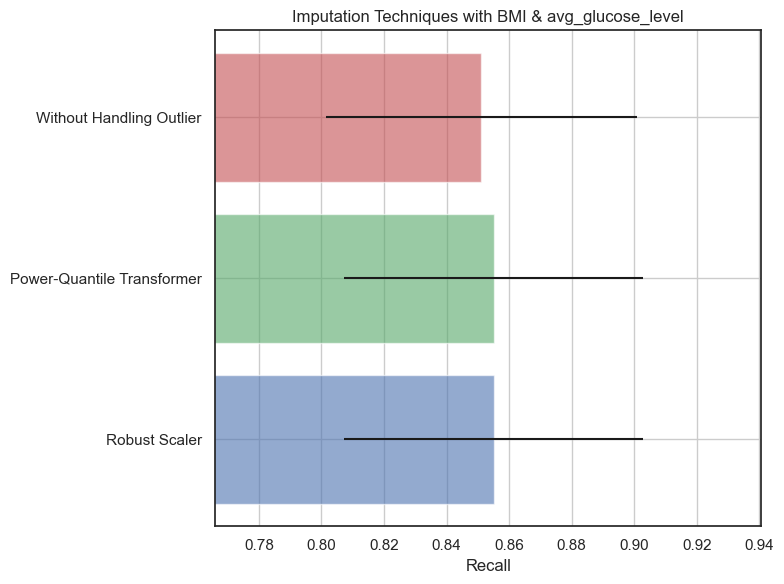

In [68]:
plot_outlier_champions(y_labels, mean_score_data, stds_data, "Recall", "BMI & avg_glucose_level")

- `bmi` , `avg_glucose_level` : outlier handling degraded the model's preformance

## Pipeline: Handle Outliers

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd
import cloudpickle

### 1. Build pipeline

In [70]:
outlier_imputer = ColumnTransformer(
            transformers=[
                (
                    'power_transform',
                    PowerTransformer(method='yeo-johnson'),
                    ['bmi']
                ),
                (
                    'quantile_transform',
                    QuantileTransformer(n_quantiles=100, output_distribution='normal'),
                    ['avg_glucose_level']
                )
            ], 
            remainder='passthrough',
            verbose_feature_names_out=False
        )

In [71]:
outlier_imputer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transform', ...), ('quantile_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_n

### 3. Save pipeline & Data

In [72]:
with open(ARTIFACT_FILE_NAME["handle_outlier"], "wb") as f:
    cloudpickle.dump(outlier_imputer, f)

with open(ARTIFACT_FILE_NAME["handle_outlier"], "rb") as f:
    pipeline = cloudpickle.load(f)

In [73]:
pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transform', ...), ('quantile_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_n

In [ ]:
# Make sure to close the run so MLflow knows the notebook is done
mlflow.end_run()

### **Next Action:**

- Perfrom multivariate analysis
    - see combined effect of features towards target